##### Contexto

Nuestro equipo de especialistas en ciencias del comportamiento ha trabajado con un cliente codo con codo para aumentar la proporción de usuarios finales que abren un email y pinchan en un banner dentro del email.
Han probado distintos tratamientos y nos han devuelto los datos. Ahora tenemos que analizar dichos datos y explicárselos al cliente creando un data storytelling que sea adecuado para que el cliente entienda a la perfección nuestro análisis y los resultados obtenidos.


##### Importe de librerías

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import lilliefors

##### Carga de datos

In [26]:
df = pd.read_csv("/Users/david/BeWay/Centro de Excelencia - Datos/Bases de datos/datos_prueba_tecnica.csv", encoding='latin-1', sep=',')
df.head()

,iid,grupo,or,ctor,sexo,edad,inve,uso_app,tarjeta_debito,tipo_tarjeta,formacion
0,1,ctrl,0,0,0,38.296148,51019.88612,1,0,3,2
1,2,trat1,1,1,1,54.470670,63337.21881,1,0,3,4
2,3,trat2,1,1,1,35.713804,59901.62123,1,0,3,3
3,4,trat1,0,0,1,49.614319,50422.66906,0,0,3,3
4,5,trat1,0,0,1,41.816158,45562.30864,0,1,3,3


### Exploratory Data Anlysis (EDA)

##### Inspección de los datos

In [27]:
# Check column data types and non-missing values
print("Column data types and non-missing values:")
print(df.info())

# Print the first five rows of the DataFrame
print("\n First five rows of the DataFrame:")
print(df.head())

# Print the last five rows of the DataFrame
print("\n Last five rows of the DataFrame:")
print(df.tail())

# Print the statistics of all columns
print("\n Statistics of all columns:")
print(df.describe())

Column data types and non-missing values:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   iid             5000 non-null   int64  
 1   grupo           5000 non-null   str    
 2   or              5000 non-null   int64  
 3   ctor            5000 non-null   int64  
 4   sexo            5000 non-null   int64  
 5   edad            5000 non-null   float64
 6   inve            5000 non-null   float64
 7   uso_app         5000 non-null   int64  
 8   tarjeta_debito  5000 non-null   int64  
 9   tipo_tarjeta    5000 non-null   int64  
 10  formacion       5000 non-null   int64  
dtypes: float64(2), int64(8), str(1)
memory usage: 429.8 KB
None

 First five rows of the DataFrame:
   iid  grupo  or  ctor  sexo       edad         inve  uso_app  \
0    1   ctrl   0     0     0  38.296148  51019.88612        1   
1    2  trat1   1     1     1  54.470670  63

##### Limpieza y procesamiento de datos

In [28]:
# Convertir id a string
df['iid'] = df['iid'].astype(str)

# Convertir edad a entero
df['edad'] = df['edad'].astype(int)

# Convertir cols a categoría
catcols = ['grupo', 'or', 'ctor', 'sexo', 'uso_app', 'tarjeta_debito', 'tipo_tarjeta', 'formacion']
df[catcols] = df[catcols].astype('category')

# Reconfirmar na's
print("Valores perdidos por columnas:")
print(df.isna().sum())

# Check column data types and non-missing values
print("\n Column data types and non-missing values:")
print(df.info())

# Print the first five rows of the DataFrame
print("\n First five rows of the DataFrame:")
print(df.head())

# Print the last five rows of the DataFrame
print("\n Last five rows of the DataFrame:")
print(df.tail())

# Print the statistics of all columns
print("\n Statistics of all columns:")
print(df.describe())

Valores perdidos por columnas:
iid               0
grupo             0
or                0
ctor              0
sexo              0
edad              0
inve              0
uso_app           0
tarjeta_debito    0
tipo_tarjeta      0
formacion         0
dtype: int64

 Column data types and non-missing values:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   iid             5000 non-null   str     
 1   grupo           5000 non-null   category
 2   or              5000 non-null   category
 3   ctor            5000 non-null   category
 4   sexo            5000 non-null   category
 5   edad            5000 non-null   int64   
 6   inve            5000 non-null   float64 
 7   uso_app         5000 non-null   category
 8   tarjeta_debito  5000 non-null   category
 9   tipo_tarjeta    5000 non-null   category
 10  formacion       5000 non-null   categor

##### Exploración por variables

In [29]:
# Análisis de id
print("\n Análisis iid")
print(f"Número de valores únicos (IDs): {df['iid'].nunique()}")


 Análisis iid
Número de valores únicos (IDs): 5000



--- Estadísticas Numéricas ---
Estadísticas de edad:
 count    5000.000000
mean       46.761000
std        11.152881
min        18.000000
25%        39.000000
50%        47.000000
75%        54.000000
max        70.000000
Name: edad, dtype: float64

Estadísticas de inversión (inve):
 count     5000.000000
mean     49477.863491
std      10913.533755
min      20689.644810
25%      41616.960403
50%      48159.059205
75%      57818.409473
max      82603.697460
Name: inve, dtype: float64


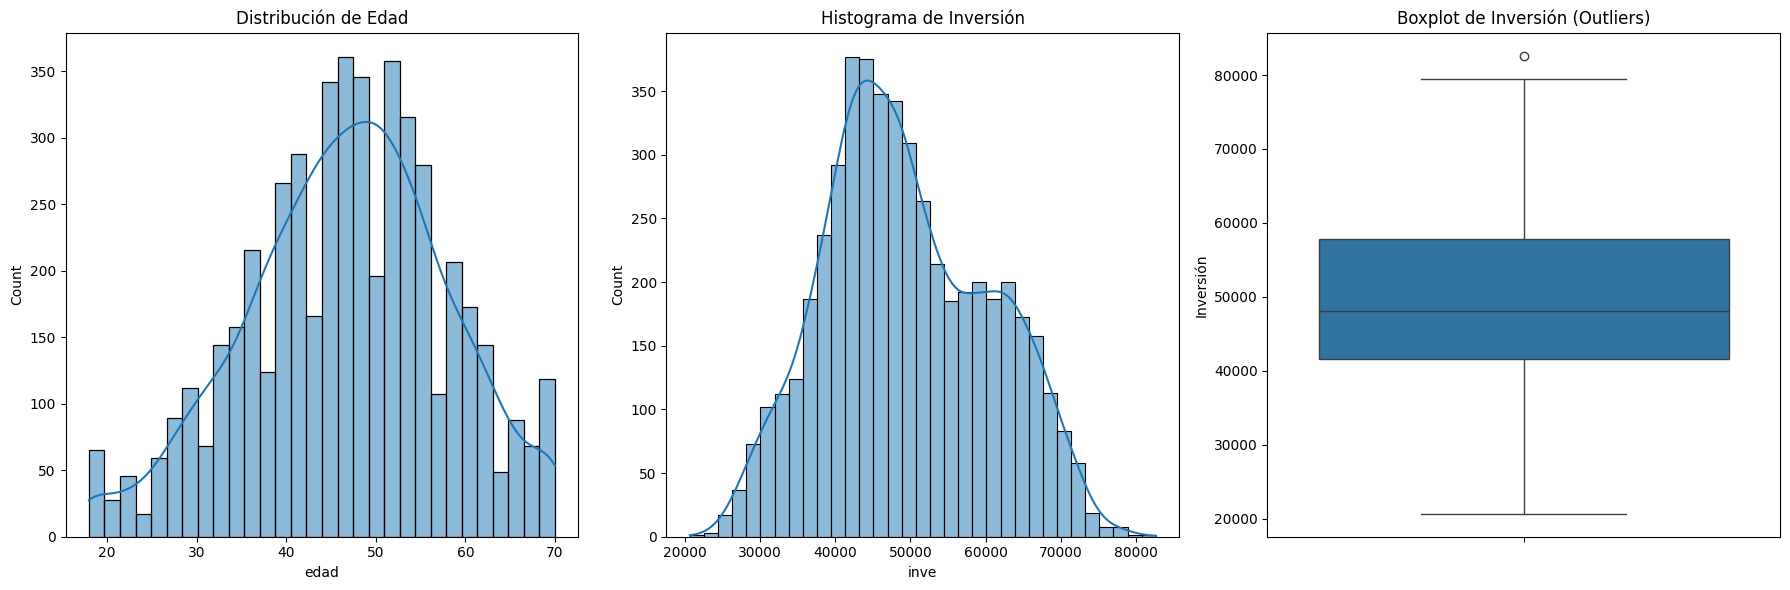

In [30]:
# Medidas de tendencia central y dispersión para edad e ingresos
print("\n--- Estadísticas Numéricas ---")
# Descripción general de las estadísticas
print("Estadísticas de edad:\n", df['edad'].describe())
print("\nEstadísticas de inversión (inve):\n", df['inve'].describe())

plt.figure(figsize=(18, 6)) # Ajustamos el tamaño para acomodar tres plots

# PLOT 1: Edad (R1, C1)
plt.subplot(1, 3, 1)  # Indicamos 3 columnas
sns.histplot(df['edad'], kde=True)
plt.title('Distribución de Edad')

# PLOT 2: Inversión Histograma (R1, C2)
plt.subplot(1, 3, 2) # Indicamos la segunda columna
sns.histplot(df['inve'], kde=True)
plt.title('Histograma de Inversión')

# PLOT 3: Inversión Boxplot (R1, C3)
plt.subplot(1, 3, 3) # Indicamos la tercera columna
sns.boxplot(y=df['inve'])
plt.title('Boxplot de Inversión (Outliers)')
plt.ylabel('Inversión')


plt.tight_layout()
plt.show()


--- Análisis de Variables Binarias ---


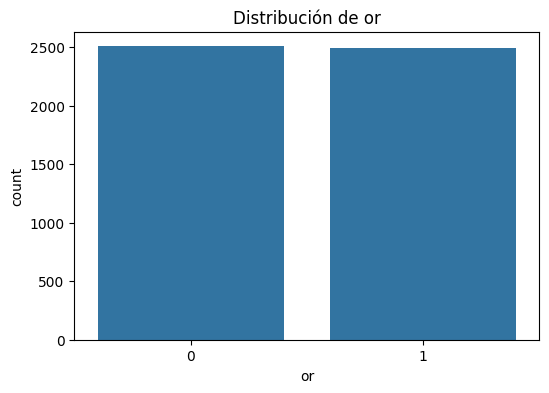

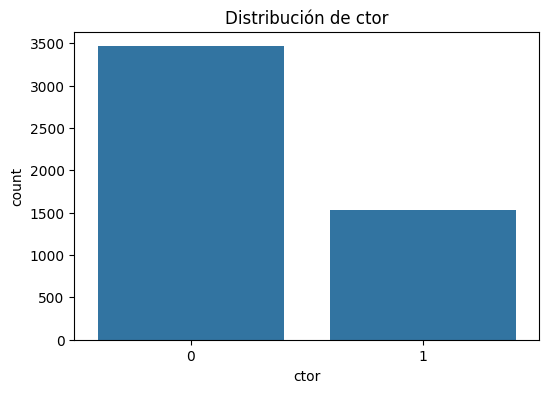

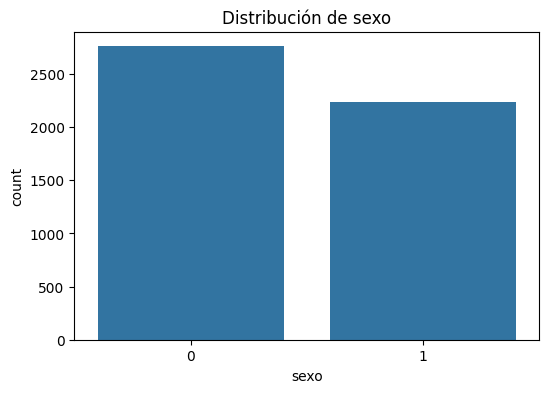

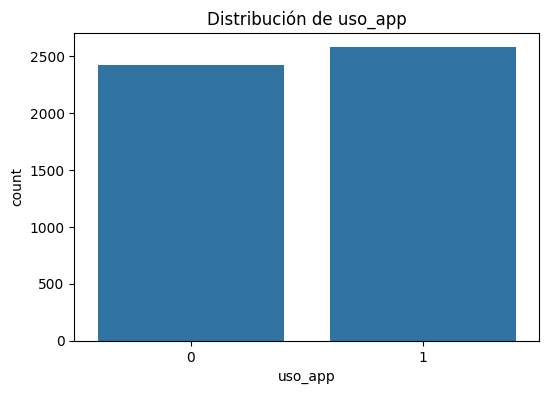

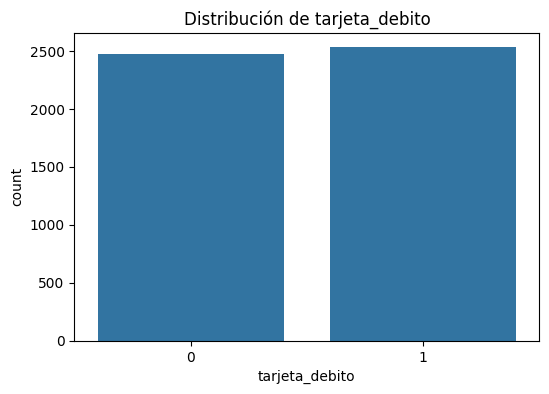

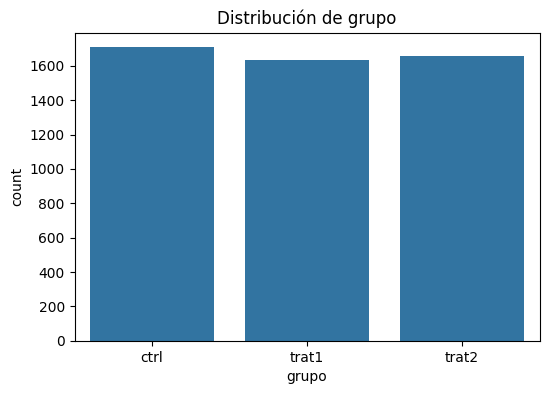

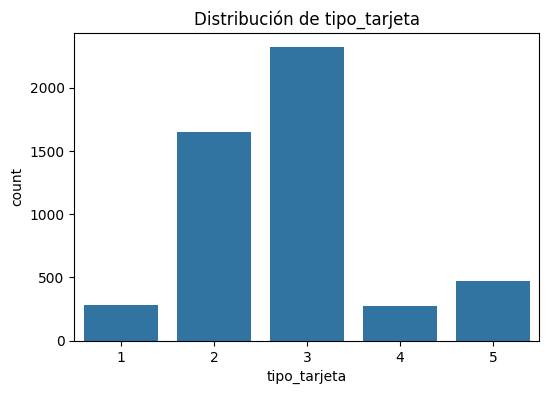

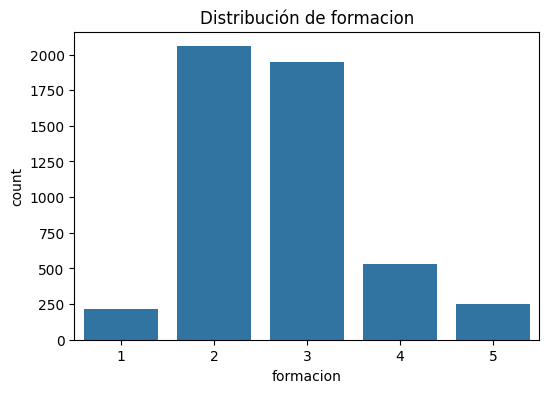

In [31]:
# Análisis de variables categóricas (grupo, sexo, uso_app, tarjeta_debito, tipo_tarjeta)
print("\n--- Análisis de Variables Binarias ---")
for var in ['or', 'ctor', 'sexo', 'uso_app', 'tarjeta_debito','grupo', 'tipo_tarjeta', 'formacion']:
    plt.figure(figsize=(6, 4))
    # Contablet es mejor para contar frecuencias en variables binarias/categóricas
    sns.countplot(x=df[var])
    plt.title(f'Distribución de {var}')
    plt.show()

##### Definición de funciones
Definición de funciones de razón para exploración rápida y precisa 

In [32]:
#Creación de función para el open rate
def open_rate(dataframe, column_names):
    # Agrupa por las columnas indicadas y cuenta los usuarios únicos que abrieron
    opened = dataframe[dataframe['or'] == 1].groupby(column_names)['iid'].nunique()
    
    # Agrupa por las columnas indicadas y cuenta el total de usuarios únicos
    total_users = dataframe.groupby(column_names)['iid'].nunique()
        
    # Calcula la tasa de apertura
    open_rate = round(opened / total_users * 100, 1)
    
    return open_rate

#Creación de función para el click to open rate
def ctor_rate(dataframe, column_names):
    # Agrupa por las columnas indicadas y cuenta los usuarios únicos que abrieron
    clicked = dataframe[(dataframe['or'] == 1) & (dataframe['ctor'] == 1)].groupby(column_names)['iid'].nunique()
    
    # Agrupa por las columnas indicadas y cuenta el total de usuarios únicos
    opened = dataframe[dataframe['or'] == 1].groupby(column_names)['iid'].nunique()
        
    # Calcula la tasa de apertura
    ctor_rate = round(clicked / opened * 100, 1)
    
    return ctor_rate

##### Cálculo de razones

In [33]:
# Exploración del open rate
print("\n--- Open Rate por Grupo de tratamiento ---") 
resultado_open = open_rate(df, ['grupo'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Exploración del click to open rate
print("\n--- Click to Open Rate por Grupo de tratamiento ---") 
resultado_ctor = ctor_rate(df, ['grupo'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)

#Subsetting para el análisis de open rate y click to open rate por grupo de tratamiento más efectivo (trat2).
most_effective_group = df[df['grupo'] == 'trat2']
print("\n--- Subsetting ---")
print(most_effective_group.head())


--- Open Rate por Grupo de tratamiento ---
              0
    grupo      
iid ctrl   28.8
    trat1  60.8
    trat2  60.8

--- Click to Open Rate por Grupo de tratamiento ---
              0
    grupo      
iid ctrl   30.3
    trat1  58.0
    trat2  80.4

--- Subsetting ---
   iid  grupo or ctor sexo  edad         inve uso_app tarjeta_debito  \
2    3  trat2  1    1    1    35  59901.62123       1              0   
6    7  trat2  0    0    1    47  51766.10450       0              1   
8    9  trat2  0    0    1    53  46557.81233       0              0   
9   10  trat2  0    0    1    64  46647.51791       1              1   
11  12  trat2  1    1    0    48  58635.13769       1              1   

   tipo_tarjeta formacion  
2             3         3  
6             2         5  
8             3         5  
9             2         2  
11            3         2  


In [34]:
# Exploración del open rate para most_effective_group si tiene tarjeta_debito y tipo_tarjeta (mayor cantidad)


print("\n--- Open Rate por Grupo de tratamiento ---") 
resultado_open = open_rate(most_effective_group, ['tarjeta_debito', 'tipo_tarjeta', 'sexo'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Exploración del click to open rate
print("\n--- Click to Open Rate por Grupo de tratamiento ---") 
resultado_ctor = ctor_rate(most_effective_group, ['tarjeta_debito', 'tipo_tarjeta', 'sexo'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)


--- Open Rate por Grupo de tratamiento ---
                      iid                        
tipo_tarjeta            1     2     3     4     5
tarjeta_debito sexo                              
0              0     76.9  44.7  78.6  59.5  59.5
               1     53.8  23.9  57.7  44.4  40.9
1              0     60.0  39.1  81.4  64.0  64.7
               1     45.5  25.9  62.3  45.0  58.1

--- Click to Open Rate por Grupo de tratamiento ---
                       iid                        
tipo_tarjeta             1     2     3     4     5
tarjeta_debito sexo                               
0              0     100.0  54.2  91.8  77.3  77.3
               1      71.4  33.3  79.1  87.5  66.7
1              0      90.5  71.1  89.3  68.8  87.9
               1      60.0  22.7  70.3  77.8  83.3


##### Transformar variables numéricas a categóricas

In [ ]:
#Definición de rangos de edad (bins) y etiquetas (labels) para categorizar la edad en grupos
bins_edad = [18, 25, 35, 50, 65, 71] 
labels_edad = [
    '18 - <25',     
    '25 - <35',   
    '35 - <50', 
    '50 - <65',  
    '≥65'         
]

# pd.cut() con bins y labels definidos manualmente.
# El nombre de la columna que se crea es: grupo_edad
most_effective_group['grupo_edad'] = pd.cut(
    most_effective_group['edad'], 
    bins=bins_edad, 
    labels=labels_edad, 
    right=False, # [start, end) - Límite inferior inclusivo, superior exclusivo
    include_lowest=True
)

#Inversión en quintiles
most_effective_group['quintil_inve'] = pd.qcut(
    most_effective_group['inve'], 
    q=4, 
    labels=['Q1', 'Q2', 'Q3', 'Q4'] # Usé comillas para claridad en los labels
)

#Verificar tipo de conversión
most_effective_group['grupo_edad'] = most_effective_group['grupo_edad'].astype('category')
most_effective_group['quintil_inve'] = most_effective_group['quintil_inve'].astype('category')
print(f"Tipo de dato en 'grupo_edad': {most_effective_group['grupo_edad'].dtype}")
print(f"Tipo de dato en 'quintil_inve': {most_effective_group['quintil_inve'].dtype}")
most_effective_group.head(10)

Tipo de dato en 'grupo_edad': category
Tipo de dato en 'quintil_inve': category


In [47]:
# Exploración del open rate para most_effective_group si tiene tarjeta_debito y edad

print("\n--- Open Rate por Grupo de tratamiento ---") 
resultado_open = open_rate(most_effective_group, ['tarjeta_debito', 'grupo_edad'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Exploración del click to open rate
print("\n--- Click to Open Rate por Grupo de tratamiento ---") 
resultado_ctor = ctor_rate(most_effective_group, ['tarjeta_debito', 'grupo_edad'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)


--- Open Rate por Grupo de tratamiento ---
                    iid                                 
grupo_edad     18 - <25 25 - <35 35 - <50 50 - <65   ≥65
tarjeta_debito                                          
0                  95.1     90.6     61.8     27.5  15.2
1                  98.7     92.6     61.1     30.0  26.1

--- Click to Open Rate por Grupo de tratamiento ---
                    iid                               
grupo_edad     18 - <25 25 - <35 35 - <50 50 - <65 ≥65
tarjeta_debito                                        
0                 100.0     95.8     77.9     39.3 NaN
1                 100.0     97.5     73.8     43.1 NaN


In [50]:
# Exploración del open rate para most_effective_group si tiene tarjeta_debito y inversión

print("\n--- Open Rate por Grupo de tratamiento ---") 
resultado_open = open_rate(most_effective_group, ['tipo_tarjeta', 'quintil_inve'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Exploración del click to open rate
print("\n--- Click to Open Rate por Grupo de tratamiento ---") 
resultado_ctor = ctor_rate(most_effective_group, ['tipo_tarjeta', 'quintil_inve'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)


--- Open Rate por Grupo de tratamiento ---
               iid                   
quintil_inve    Q1    Q2    Q3     Q4
tipo_tarjeta                         
1             33.3  12.0  88.9  100.0
2             22.4  20.5  76.9   94.7
3             24.2  40.6  95.2   99.6
4             34.6  14.3  83.3  100.0
5             15.8  28.6  93.1  100.0

--- Click to Open Rate por Grupo de tratamiento ---
             iid                    
quintil_inve  Q1    Q2     Q3     Q4
tipo_tarjeta                        
1            NaN  33.3  100.0  100.0
2            NaN   9.4   92.5  100.0
3            NaN  37.7   96.8  100.0
4            NaN  25.0   95.0  100.0
5            NaN  10.0  100.0  100.0


##### Análisis inferencial

In [ ]:
#Pruebas de normalidad

# 1. Prueba de Kolmogorov-Smirnov (K-S)
# Requiere pasar la media y desviación estándar de la muestra como argumentos.
ks_stat, ks_p_valor = stats.kstest(df['edad'].dropna(), 'norm', args=(df['edad'].mean(), df['edad'].std()))
print(f"Estadístico K-S: {ks_stat}, p-valor: {ks_p_valor}")

# 2. Prueba de Lilliefors (Variante de K-S recomendada cuando los parámetros se estiman de la muestra)
lf_stat, lf_p_valor = lilliefors(df['edad'].dropna(), dist='norm')
print(f"Estadístico Lilliefors: {lf_stat}, p-valor: {lf_p_valor}")

# 3. Prueba de Shapiro-Wilk (Alternativa con mayor poder estadístico para normalidad)
sw_stat, sw_p_valor = stats.shapiro(df['edad'].dropna())
print(f"Estadístico Shapiro-Wilk: {sw_stat}, p-valor: {sw_p_valor}")